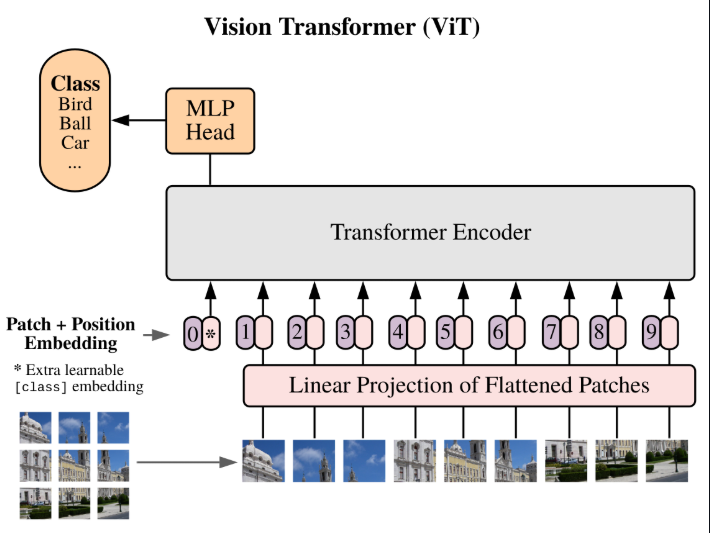

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch import nn
from torch import Tensor
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange, Reduce
from torchsummary import summary


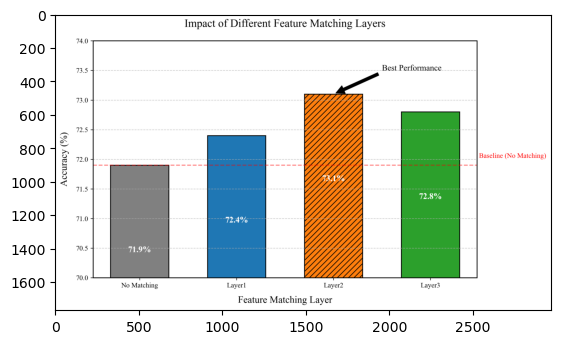

In [3]:
img = Image.open(r"E:\paper\feature_matching_impact.png")
fig = plt.figure()
plt.imshow(img)

In [4]:
# resize to imagenet size 
transform = Compose([Resize((224, 224)), ToTensor()])
x = transform(img)
x = x.unsqueeze(0) # add batch dim
x.shape

torch.Size([1, 4, 224, 224])

第一步是将图像拆解成多个区域并进行平整。
这可以用einops轻松完成。

In [5]:
patch_size = 16 # 16 pixels
pathes = rearrange(x, 'b c (h s1) (w s2) -> b (h w) (s1 s2 c)', s1=patch_size, s2=patch_size)

查看原始实现后，我发现作者为了性能提升，使用了 Conv2d 层而非线性层。这是通过使用等于 的 kernel_size 和步幅得到的。直观上，卷积操作是对每个补丁单独应用的。因此，我们必须先应用变换层，然后将生成的图像平整。patch_size

In [6]:
class PatchEmbedding(nn.Module): # patch embedding layer
    def __init__(self, in_channels: int = 4, patch_size: int = 16, emb_size: int = 768):
        self.patch_size = patch_size
        super().__init__()
        self.projection = nn.Sequential(
            # using a conv layer instead of a linear one -> performance gains
            nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )
                
    def forward(self, x: Tensor) -> Tensor:
        x = self.projection(x)
        return x
    
PatchEmbedding()(x).shape

torch.Size([1, 196, 768])

下一步是添加class token 和 位置嵌入。这只是每个序列（投影片段）中放入的一个数字。cls tokencls token

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int = 4, patch_size: int = 16, emb_size: int = 768, img_size: int = 224):
        self.patch_size = patch_size
        super().__init__()
        self.projection = nn.Sequential(
            # using a conv layer instead of a linear one -> performance gains
            nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )
        self.cls_token = nn.Parameter(torch.randn(1,1, emb_size))
        self.positions = nn.Parameter(torch.randn((img_size // patch_size) **2 + 1, emb_size))

        
    def forward(self, x: Tensor) -> Tensor:
        b, _, _, _ = x.shape
        x = self.projection(x)
        cls_tokens = repeat(self.cls_token, '() n e -> b n e', b=b)
        # prepend the cls token to the input
        x = torch.cat([cls_tokens, x], dim=1)
        # add position embedding
        x += self.positions
        return x
    
PatchEmbedding()(x).shape

torch.Size([1, 197, 768])

拼接 class token 的作用是让模型自己学习如何从整张图像中聚合信息，用于最终分类 
充当“汇总节点”
在 ViT 中，图像被切成多个 patch，每个 patch 对应一个输入 token。这些 token 之间通过自注意力互相“看”对方，但模型需要一种机制来提取全局信息用于分类。
class token 作为一个可训练的、与具体图像内容无关的向量，在自注意力过程中会与所有 patch token 交互，逐渐汇聚全图信息。

避免手动池化
如果没有 class token，通常会对所有 patch token 的输出做平均池化或最大池化，这相当于硬性规定信息融合方式。而 class token 让模型自适应地决定哪些 patch 的信息更重要，表达能力更强。

源自 BERT 的成功设计
ViT 借鉴了 BERT 的 [CLS] token 设计，在自然语言处理中，该 token 被证实能有效捕获句子级别的语义。ViT 将其迁移到视觉领域，取得了良好效果。

ViT 放弃了原始 Transformer 的固定正弦编码，采用可学习位置嵌入，这是为了适配图像 patch 的网格结构并简化实现，同时性能得到验证。

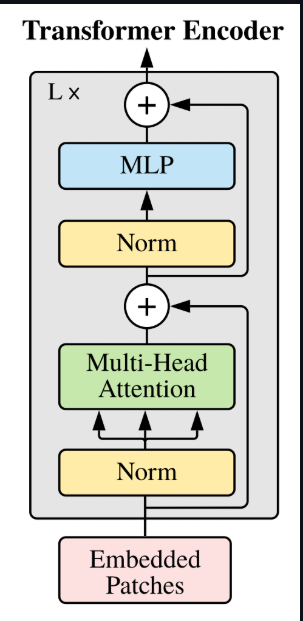

注意力接收三个输入：著名的查询、键和值，并利用查询和值计算注意力矩阵，并用它来“关注”这些值。在这种情况下，我们使用了多头注意力，意味着计算被分配到n个输入大小较小的头上。我们可以用PyTorch的软件，也可以自己实现。为了完整起见，我会展示它的样子：

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size: int = 768, num_heads: int = 8, dropout: float = 0):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.keys = nn.Linear(emb_size, emb_size)# 就相当于乘了权重矩阵 （y = x @ W^T + b） 这里的W就是权重矩阵
        self.queries = nn.Linear(emb_size, emb_size)
        self.values = nn.Linear(emb_size, emb_size)
        self.att_drop = nn.Dropout(dropout)
        self.projection = nn.Linear(emb_size, emb_size)
        self.scaling = (self.emb_size // num_heads) ** -0.5 #缩放因子

    def forward(self, x : Tensor, mask: Tensor = None) -> Tensor:
        # split keys, queries and values in num_heads
        queries = rearrange(self.queries(x), "b n (h d) -> b h n d", h=self.num_heads)
        keys = rearrange(self.keys(x), "b n (h d) -> b h n d", h=self.num_heads)
        values  = rearrange(self.values(x), "b n (h d) -> b h n d", h=self.num_heads)
        # sum up over the last axis
        energy = torch.einsum('bhqd, bhkd -> bhqk', queries, keys) # batch, num_heads, query_len, key_len
        if mask is not None:
            fill_value = torch.finfo(torch.float32).min
            energy.mask_fill(~mask, fill_value)
        energy = energy * self.scaling
        att = F.softmax(energy, dim=-1) 
        att = self.att_drop(att)
        # sum up over the third axis
        out = torch.einsum('bhal, bhlv -> bhav ', att, values) #out = torch.matmul(att, values)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.projection(out)
        return out
    
patches_embedded = PatchEmbedding()(x)
MultiHeadAttention()(patches_embedded).shape

torch.Size([1, 197, 768])

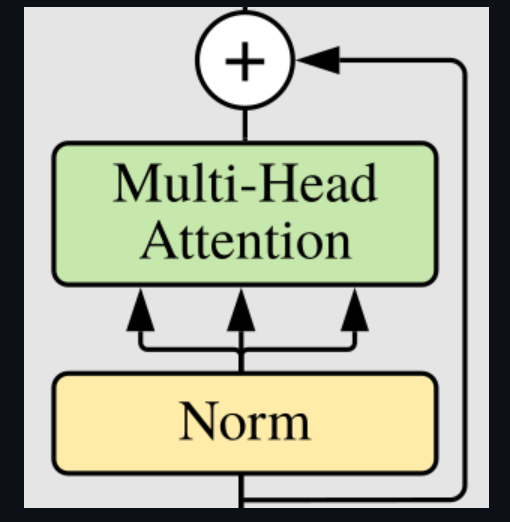

transformer模块有残余连接 我们可以创建一个简洁的包装器来执行残差加法，这在以后会很有用。

In [9]:
class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
        
    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x

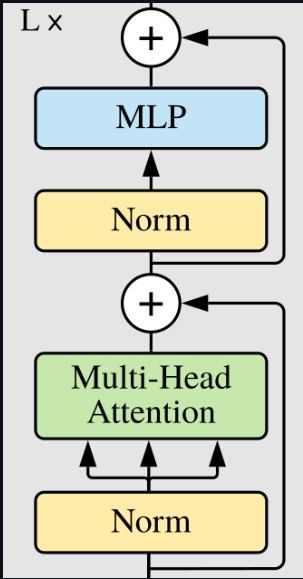

MLP 注意力机制的输出被传递到一个全连接层，该全连接层由两层组成，这两层对输入进行上采样，上采样倍数为expansion输入的1倍。

In [ ]:
class FeedForwardBlock(nn.Sequential): #前馈网络
    def __init__(self, emb_size: int, expansion: int = 4, drop_p: float = 0.):
        super().__init__()
        self.FFN = nn.Sequential(
            nn.Linear(emb_size, expansion * emb_size),
            nn.GELU(), #GELU(x) ≈ x * Φ(x) 其中 Φ(x) 是标准正态分布的累积分布函数
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),
        )
    def forward(self, x):
        x = self.FFN(x)
        return x
        

最后，我们可以创建 Transformer 编码器模块。  
   ResidualAdd这使我们能够以一种优雅的方式定义这个模块。

     

In [12]:
class TransformerEncoderBlock(nn.Sequential):
    def __init__(self,
                 emb_size: int = 768,
                 drop_p: float = 0.,
                 forward_expansion: int = 4,
                 forward_drop_p: float = 0.,
                 ** kwargs):
        super().__init__(
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                MultiHeadAttention(emb_size, **kwargs),
                nn.Dropout(drop_p)
            )),
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                FeedForwardBlock(
                    emb_size, expansion=forward_expansion, drop_p=forward_drop_p),
                nn.Dropout(drop_p)
            )
            ))
patches_embedded = PatchEmbedding()(x)
TransformerEncoderBlock()(patches_embedded).shape

torch.Size([1, 197, 768])

最后一层是普通的全连接层，用于计算类别概率。  
它首先对整个序列进行基本均值计算。

In [ ]:
class ClassificationHead(nn.Sequential):
    def __init__(self, emb_size: int = 768, n_classes: int = 1000):
        super().__init__(
            Reduce('b n e -> b e', reduction='mean'),  #x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]  提取 cls token 或者使用平均池化
            nn.LayerNorm(emb_size), 
            nn.Linear(emb_size, n_classes))

我们可以组合起来PatchEmbedding，TransformerEncoder创建 ClassificationHead最终的 ViT 架构。

In [ ]:
class ViT(nn.Sequential):
    def __init__(self,     
                in_channels: int = 3,
                patch_size: int = 16,
                emb_size: int = 768,
                img_size: int = 224,
                depth: int = 12,
                n_classes: int = 1000,
                **kwargs):
        super().__init__(
            PatchEmbedding(in_channels, patch_size, emb_size, img_size),
            *[TransformerEncoderBlock(emb_size=emb_size, **kwargs) for _ in range(depth)],
            ClassificationHead(emb_size, n_classes)
        )
        

In [ ]:
class MyModel(nn.Module):
    def __init__(self, in_channels, patch_size, emb_size, img_size, depth, n_classes, **kwargs):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, emb_size, img_size)
        self.transformer = TransformerEncoderBlock(depth, emb_size=emb_size, **kwargs)
        self.classifier = ClassificationHead(emb_size, n_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.transformer(x)
        x = self.classifier(x)
        return x

VIT-B/16  

CIFAR-10：约 96.8%（零样本推理）

CIFAR-100：约 85.1%（零样本推理）；若进行微调，可提升至 82% - 88% 左右